In [147]:
import subprocess, sys
subprocess.check_call([
    sys.executable, "-m", "pip", "install", "--quiet",
    "pandas",
    "numpy",
    "matplotlib",
    "seaborn",
    "scikit-learn",
    "scipy",
    "statsmodels",
    "ipykernel"
])
print("All packages installed successfully.")

All packages installed successfully.


# House Price Prediction Using Ridge Regression

## Project Overview

The goal of this project is to build a machine learning model that predicts house sale prices based on property characteristics.

In [148]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer


In [149]:
df = pd.read_csv(r"C:\Users\pragu\Downloads\house-prices-advanced-regression-techniques\train.csv")

In [150]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [151]:
df.shape

(1460, 81)

In [152]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [153]:
df.dtypes.value_counts()

str        43
int64      35
float64     3
Name: count, dtype: int64

In [154]:
df.select_dtypes("number").nunique()

Id               1460
MSSubClass         15
LotFrontage       110
LotArea          1073
OverallQual        10
OverallCond         9
YearBuilt         112
YearRemodAdd       61
MasVnrArea        327
BsmtFinSF1        637
BsmtFinSF2        144
BsmtUnfSF         780
TotalBsmtSF       721
1stFlrSF          753
2ndFlrSF          417
LowQualFinSF       24
GrLivArea         861
BsmtFullBath        4
BsmtHalfBath        3
FullBath            4
HalfBath            3
BedroomAbvGr        8
KitchenAbvGr        4
TotRmsAbvGrd       12
Fireplaces          4
GarageYrBlt        97
GarageCars          5
GarageArea        441
WoodDeckSF        274
OpenPorchSF       202
EnclosedPorch     120
3SsnPorch          20
ScreenPorch        76
PoolArea            8
MiscVal            21
MoSold             12
YrSold              5
SalePrice         663
dtype: int64

In [155]:
df["MSSubClass"] = df["MSSubClass"].astype("object")

## Exploratory Data Analysis
Explore the dataset to understand its structure, distributions, relationships, and potential data quality issues.

In [156]:
df["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

In [157]:
(df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

PoolQC           99.520548
MiscFeature      96.301370
Alley            93.767123
Fence            80.753425
MasVnrType       59.726027
                   ...    
MoSold            0.000000
YrSold            0.000000
SaleType          0.000000
SaleCondition     0.000000
SalePrice         0.000000
Length: 81, dtype: float64

In [158]:
df.duplicated().sum()


np.int64(0)

### Sale Price Distribution

Visualize the distribution of house prices and identify potential outliers.

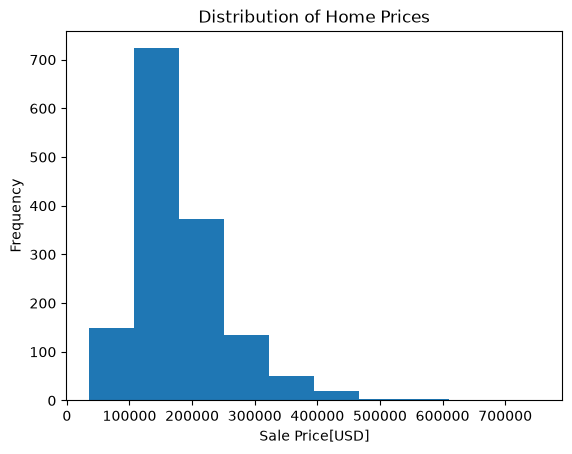

In [159]:
plt.hist(df["SalePrice"])
plt.xlabel("Sale Price[USD]")
plt.ylabel("Frequency")
plt.title("Distribution of Home Prices")
plt.show()

C:\Users\pragu\AppData\Local\Temp\ipykernel_7820\1318592382.py:1: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df["SalePrice"],vert=False)


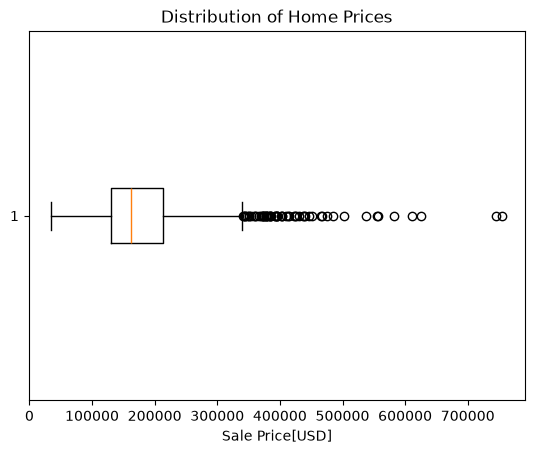

In [160]:
plt.boxplot(df["SalePrice"],vert=False)
plt.xlabel("Sale Price[USD]")
plt.title("Distribution of Home Prices");

In [161]:
[col for col in df.columns if "Area" in col]

['LotArea', 'MasVnrArea', 'GrLivArea', 'GarageArea', 'PoolArea']

In [162]:
df[["LotArea","MasVnrArea","GrLivArea","GarageArea","PoolArea"]].describe()

,LotArea,MasVnrArea,GrLivArea,GarageArea,PoolArea
count,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000
mean,10516.828082,103.685262,1515.463699,472.980137,2.758904
std,9981.264932,181.066207,525.480383,213.804841,40.177307
min,1300.000000,0.000000,334.000000,0.000000,0.000000
25%,7553.500000,0.000000,1129.500000,334.500000,0.000000
50%,9478.500000,0.000000,1464.000000,480.000000,0.000000
75%,11601.500000,166.000000,1776.750000,576.000000,0.000000
max,215245.000000,1600.000000,5642.000000,1418.000000,738.000000


In [163]:
df[["LotArea","MasVnrArea","GrLivArea","GarageArea","PoolArea"]].isnull().sum()

LotArea       0
MasVnrArea    8
GrLivArea     0
GarageArea    0
PoolArea      0
dtype: int64

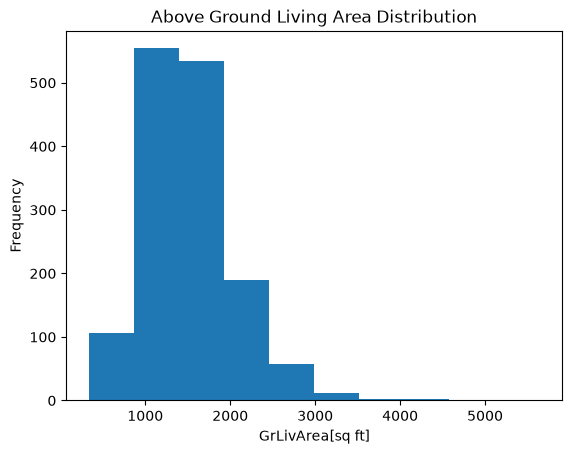

In [164]:
plt.hist(df["GrLivArea"])
plt.xlabel("GrLivArea[sq ft]")
plt.ylabel("Frequency")
plt.title("Above Ground Living Area Distribution")
plt.show()

C:\Users\pragu\AppData\Local\Temp\ipykernel_7820\2755457598.py:1: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df["GrLivArea"],vert=False)


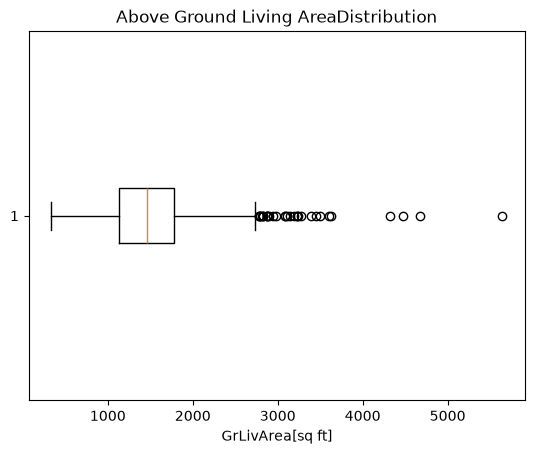

In [165]:
plt.boxplot(df["GrLivArea"],vert=False)
plt.xlabel("GrLivArea[sq ft]")
plt.title("Above Ground Living AreaDistribution");

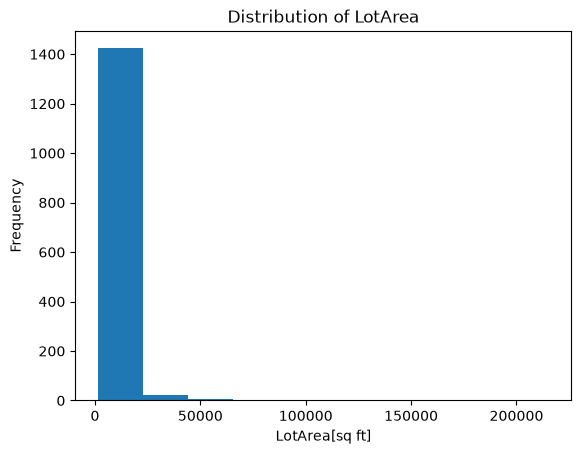

In [166]:
plt.hist(df["LotArea"])
plt.xlabel("LotArea[sq ft]")
plt.ylabel("Frequency")
plt.title("Distribution of LotArea")
plt.show()

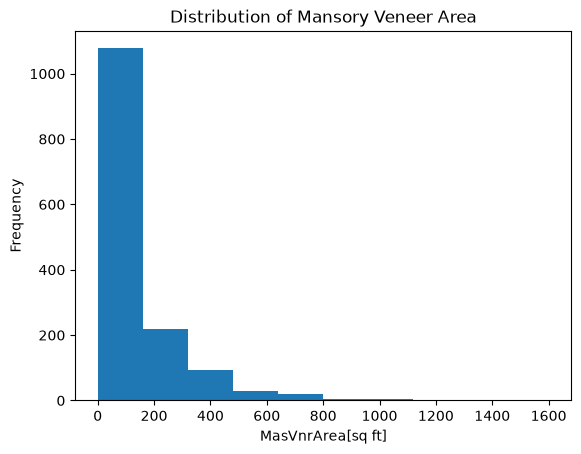

In [167]:
plt.hist(df["MasVnrArea"])
plt.xlabel("MasVnrArea[sq ft]")
plt.ylabel("Frequency")
plt.title("Distribution of Mansory Veneer Area")
plt.show()

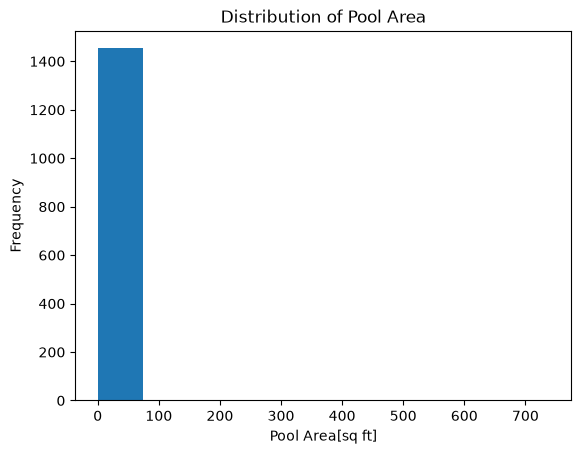

In [168]:
plt.hist(df["PoolArea"])
plt.xlabel("Pool Area[sq ft]")
plt.ylabel("Frequency")
plt.title("Distribution of Pool Area")
plt.show()

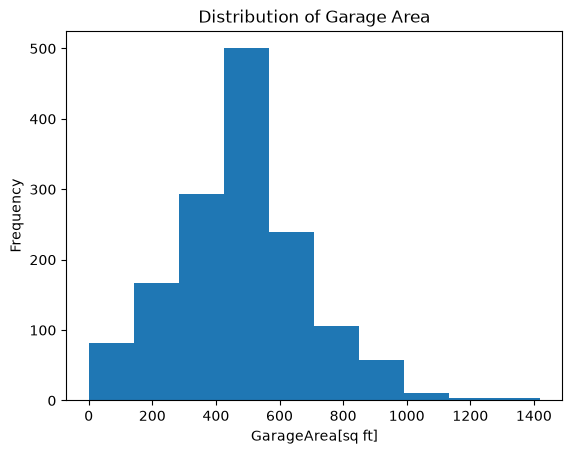

In [169]:
plt.hist(df["GarageArea"])
plt.xlabel("GarageArea[sq ft]")
plt.ylabel("Frequency")
plt.title("Distribution of Garage Area")
plt.show()

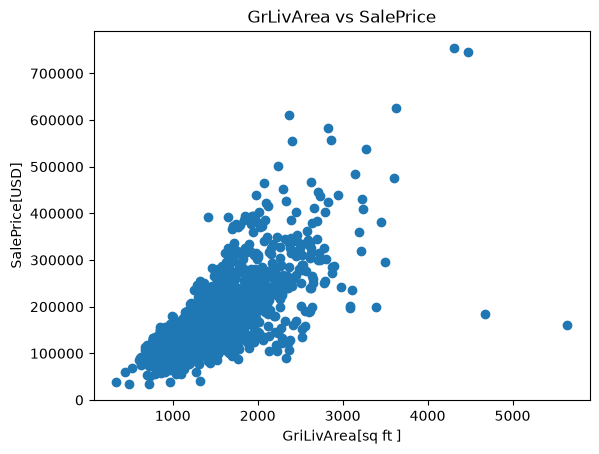

In [170]:
plt.scatter(x=df["GrLivArea"],y=df["SalePrice"])
plt.xlabel("GriLivArea[sq ft ]")
plt.ylabel("SalePrice[USD]")
plt.title("GrLivArea vs SalePrice")
plt.show()

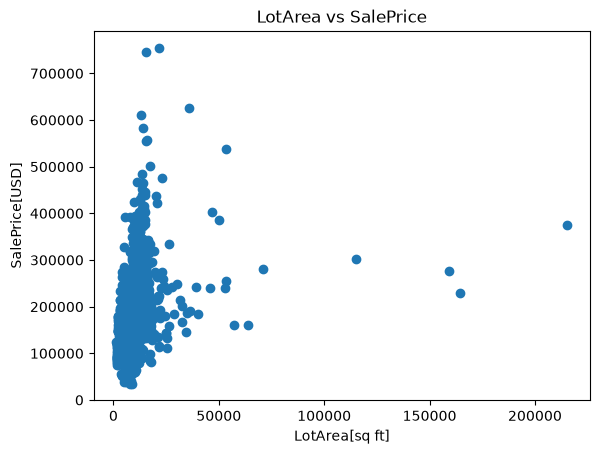

In [171]:
plt.scatter(x=df["LotArea"],y=df["SalePrice"])
plt.xlabel("LotArea[sq ft]")
plt.ylabel("SalePrice[USD]")
plt.title("LotArea vs SalePrice")
plt.show()

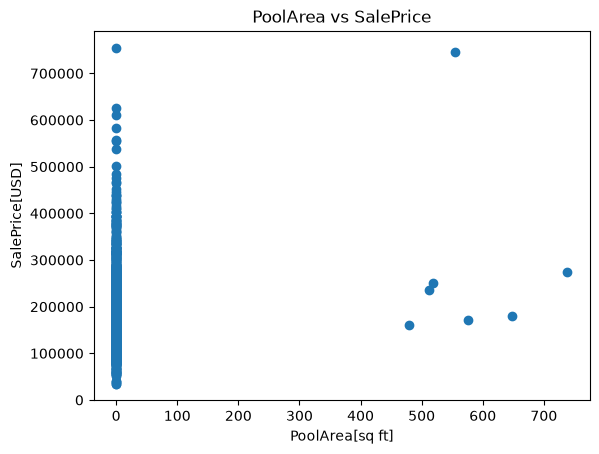

In [172]:
plt.scatter(x=df["PoolArea"],y=df["SalePrice"])
plt.xlabel("PoolArea[sq ft]")
plt.ylabel("SalePrice[USD]")
plt.title("PoolArea vs SalePrice")
plt.show()

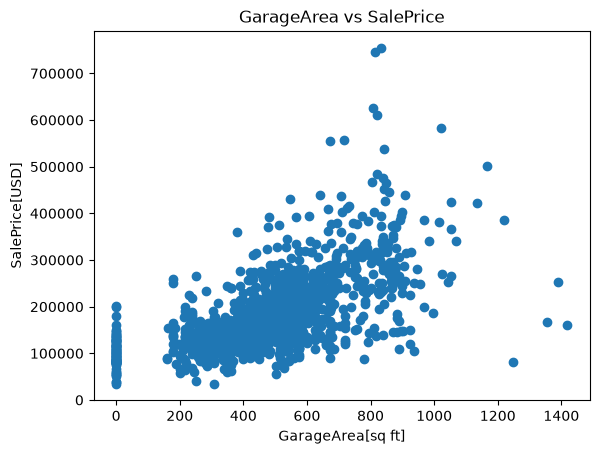

In [173]:
plt.scatter(x=df["GarageArea"],y=df["SalePrice"])
plt.xlabel("GarageArea[sq ft]")
plt.ylabel("SalePrice[USD]")
plt.title("GarageArea vs SalePrice")
plt.show()

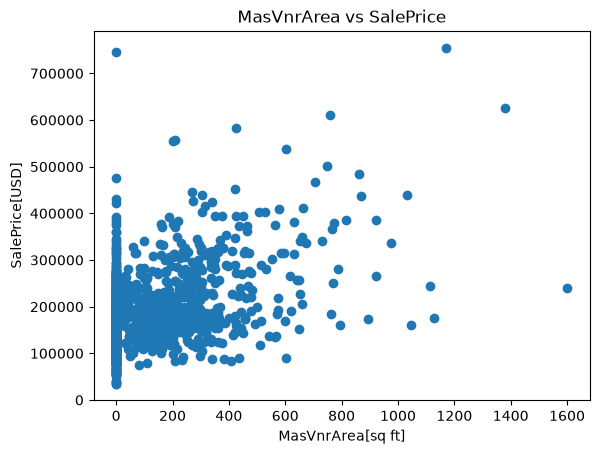

In [174]:
plt.scatter(x=df["MasVnrArea"],y=df["SalePrice"])
plt.xlabel("MasVnrArea[sq ft]")
plt.ylabel("SalePrice[USD]")
plt.title("MasVnrArea vs SalePrice")
plt.show()

In [175]:
area_cols = ["LotArea", "MasVnrArea", "GrLivArea", "GarageArea", "PoolArea"]

df[area_cols + ["SalePrice"]].corr()["SalePrice"].sort_values(ascending=False)


SalePrice     1.000000
GrLivArea     0.708624
GarageArea    0.623431
MasVnrArea    0.477493
LotArea       0.263843
PoolArea      0.092404
Name: SalePrice, dtype: float64



> **Observation:** The scatter plots and correlation analysis show that the area features generally have a positive relationship with `SalePrice`. `GrLivArea` and `GarageArea` have the strongest relationships with sale price, while `LotArea`, `MasVnrArea`, and `PoolArea` show weaker relationships. Some potential outliers are also visible, particularly in `GrLivArea`.




In [176]:
df.select_dtypes("object").nunique()

C:\Users\pragu\AppData\Local\Temp\ipykernel_7820\3517814742.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes("object").nunique()


MSSubClass       15
MSZoning          5
Street            2
Alley             2
LotShape          4
LandContour       4
Utilities         2
LotConfig         5
LandSlope         3
Neighborhood     25
Condition1        9
Condition2        8
BldgType          5
HouseStyle        8
RoofStyle         6
RoofMatl          8
Exterior1st      15
Exterior2nd      16
MasVnrType        3
ExterQual         4
ExterCond         5
Foundation        6
BsmtQual          4
BsmtCond          4
BsmtExposure      4
BsmtFinType1      6
BsmtFinType2      6
Heating           6
HeatingQC         5
CentralAir        2
Electrical        5
KitchenQual       4
Functional        7
FireplaceQu       5
GarageType        6
GarageFinish      3
GarageQual        5
GarageCond        5
PavedDrive        3
PoolQC            3
Fence             4
MiscFeature       4
SaleType          9
SaleCondition     6
dtype: int64

In [177]:
mean_price_by_neighborhood = df.groupby("Neighborhood")["SalePrice"].mean().sort_values(ascending=False)
mean_price_by_neighborhood

Neighborhood
NoRidge    335295.317073
NridgHt    316270.623377
StoneBr    310499.000000
Timber     242247.447368
Veenker    238772.727273
Somerst    225379.837209
ClearCr    212565.428571
Crawfor    210624.725490
CollgCr    197965.773333
Blmngtn    194870.882353
Gilbert    192854.506329
NWAmes     189050.068493
SawyerW    186555.796610
Mitchel    156270.122449
NAmes      145847.080000
NPkVill    142694.444444
SWISU      142591.360000
Blueste    137500.000000
Sawyer     136793.135135
OldTown    128225.300885
Edwards    128219.700000
BrkSide    124834.051724
BrDale     104493.750000
IDOTRR     100123.783784
MeadowV     98576.470588
Name: SalePrice, dtype: float64

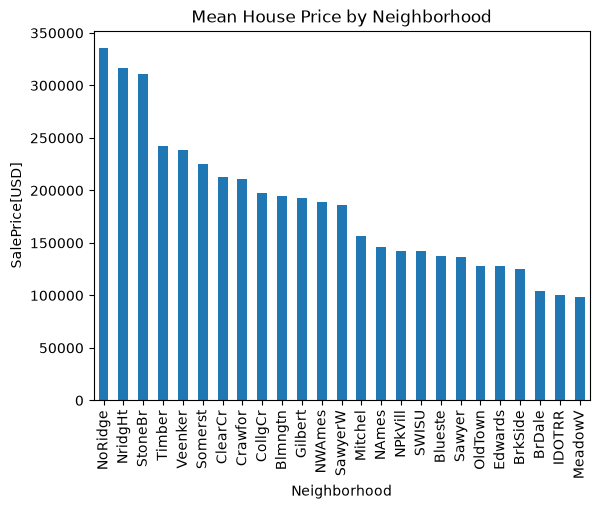

In [178]:
mean_price_by_neighborhood.plot(kind="bar",
                                xlabel="Neighborhood",
                                ylabel="SalePrice[USD]",
                                title="Mean House Price by Neighborhood");


In [179]:
df["Price_per_sqft"] = df["SalePrice"] / df["GrLivArea"]

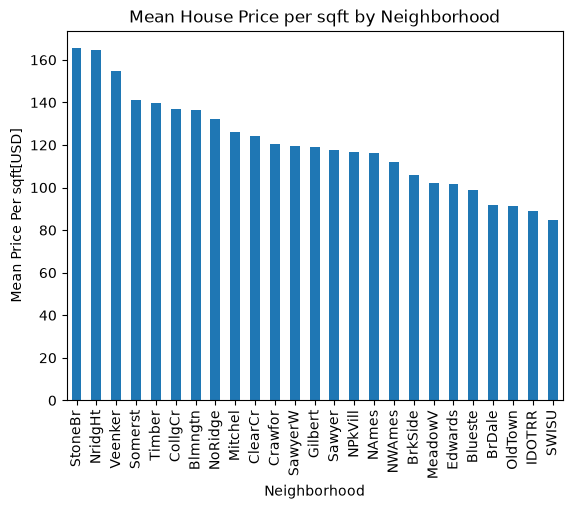

In [180]:
df.groupby("Neighborhood")["Price_per_sqft"].mean().sort_values(ascending=False).plot(kind="bar",
                                                                                    xlabel="Neighborhood",
                                                                                    ylabel="Mean Price Per sqft[USD]",
                                                                                    title="Mean House Price per sqft by Neighborhood");



> **Observation:** Neighborhood rankings differ when comparing average sale price with average price per square foot. NoRidge has the highest average sale price, while StoneBr has the highest price per square foot. This suggests that high total house prices may partly reflect larger homes, whereas price per square foot provides a size-adjusted view of neighborhood value.




In [181]:
df.groupby("OverallQual")["SalePrice"].mean().sort_values(ascending=False)

OverallQual
10    438588.388889
9     367513.023256
8     274735.535714
7     207716.423197
6     161603.034759
5     133523.347607
4     108420.655172
3      87473.750000
2      51770.333333
1      50150.000000
Name: SalePrice, dtype: float64

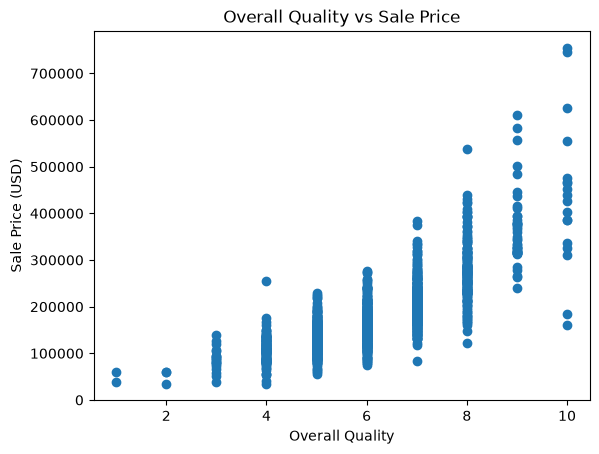

In [182]:
plt.scatter(x=df["OverallQual"], y=df["SalePrice"])

plt.xlabel("Overall Quality")
plt.ylabel("Sale Price (USD)")
plt.title("Overall Quality vs Sale Price")

plt.show()

> **Observation:** Overall quality has a strong positive relationship with sale price. Higher-quality houses generally sell for substantially higher prices, suggesting that `OverallQual` is an important predictor of `SalePrice`.


In [183]:
df["YearBuiltGroup"] = (df["YearBuilt"] // 10) * 10

df.groupby("YearBuiltGroup")["SalePrice"].mean()

YearBuiltGroup
1870    108000.000000
1880    170425.571429
1890    216316.666667
1900    129828.400000
1910    131511.482759
1920    123268.350515
1930    144415.833333
1940    126887.481013
1950    140935.670659
1960    153852.640000
1970    152828.335106
1980    190080.327869
1990    228404.220859
2000    242046.416021
2010    394432.000000
Name: SalePrice, dtype: float64

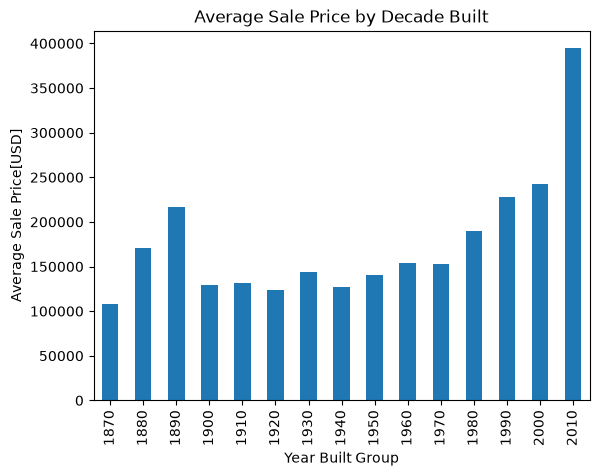

In [184]:
df.groupby("YearBuiltGroup")["SalePrice"].mean().plot(kind="bar")

plt.xlabel("Year Built Group")
plt.ylabel("Average Sale Price[USD]")
plt.title("Average Sale Price by Decade Built")
plt.show()



> **Observation:** Average sale prices generally increase for more recently built homes, especially from the 1980s onward. Homes built in the 2010s have the highest average sale price, suggesting that newer homes tend to sell for higher prices.


In [185]:
df.groupby("OverallCond")["SalePrice"].mean()

OverallCond
1     61000.000000
2    141986.400000
3    101929.400000
4    120438.438596
5    203146.914738
6    153961.591270
7    158145.487805
8    155651.736111
9    216004.545455
Name: SalePrice, dtype: float64

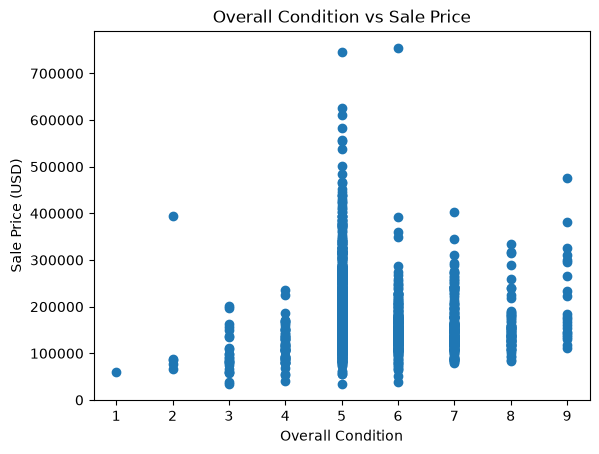

In [186]:
plt.scatter(x=df["OverallCond"], y=df["SalePrice"])

plt.xlabel("Overall Condition")
plt.ylabel("Sale Price (USD)")
plt.title("Overall Condition vs Sale Price")

plt.show()



> **Observation:** `OverallCond` does not show a strong positive relationship with `SalePrice`. Most houses are rated around condition 5, and sale prices vary widely within the same condition rating, suggesting that overall condition alone is not a strong predictor of house price


In [187]:
df.groupby("HouseStyle")["SalePrice"].mean().sort_values(ascending=False)

HouseStyle
2.5Fin    220000.000000
2Story    210051.764045
1Story    175985.477961
SLvl      166703.384615
2.5Unf    157354.545455
1.5Fin    143116.740260
SFoyer    135074.486486
1.5Unf    110150.000000
Name: SalePrice, dtype: float64

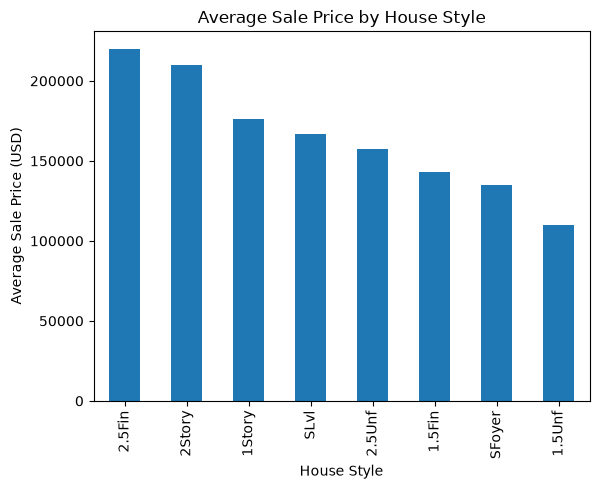

In [188]:


df.groupby("HouseStyle")["SalePrice"].mean().sort_values(ascending=False).plot(kind="bar")
plt.xlabel("House Style")
plt.ylabel("Average Sale Price (USD)")
plt.title("Average Sale Price by House Style")
plt.show()





> **Observation:** Average sale price varies by house style. `2.5Fin` and `2Story` homes have the highest average sale prices, while `1.5Unf` homes have the lowest, suggesting that house style may influence sale price.


In [189]:
df.groupby("KitchenQual")["SalePrice"].mean().sort_values(ascending=False)

KitchenQual
Ex    328554.670000
Gd    212116.023891
TA    139962.511565
Fa    105565.205128
Name: SalePrice, dtype: float64

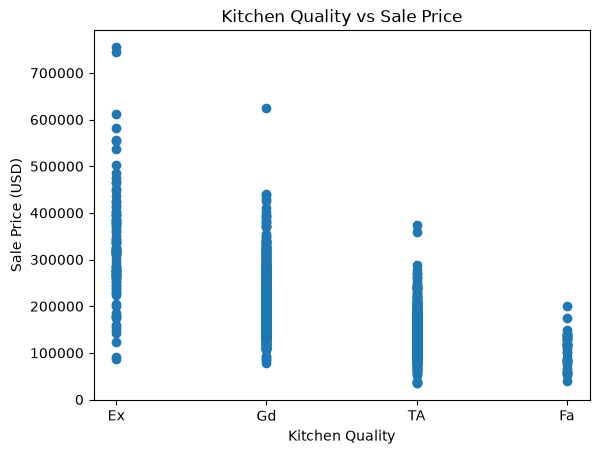

In [190]:
order = ["Ex", "Gd", "TA", "Fa", "Po"]

df["KitchenQual"] = pd.Categorical(
    df["KitchenQual"],
    categories=order,
    ordered=True
)

df = df.sort_values("KitchenQual")

plt.scatter(x=df["KitchenQual"],y= df["SalePrice"])
plt.xlabel("Kitchen Quality")
plt.ylabel("Sale Price (USD)")
plt.title("Kitchen Quality vs Sale Price")
plt.show()



> **Observation:** Kitchen quality shows a clear relationship with sale price. Houses with excellent kitchens have the highest average sale prices, while houses with fair kitchens have the lowest, suggesting that `KitchenQual` is an important predictor of `SalePrice`.


In [191]:
corr = df.select_dtypes("number").corr()
corr["SalePrice"].sort_values(ascending=False)

SalePrice         1.000000
OverallQual       0.790982
GrLivArea         0.708624
GarageCars        0.640409
GarageArea        0.623431
TotalBsmtSF       0.613581
1stFlrSF          0.605852
Price_per_sqft    0.575505
FullBath          0.560664
TotRmsAbvGrd      0.533723
YearBuilt         0.522897
YearBuiltGroup    0.515824
YearRemodAdd      0.507101
GarageYrBlt       0.486362
MasVnrArea        0.477493
Fireplaces        0.466929
BsmtFinSF1        0.386420
LotFrontage       0.351799
WoodDeckSF        0.324413
2ndFlrSF          0.319334
OpenPorchSF       0.315856
HalfBath          0.284108
LotArea           0.263843
BsmtFullBath      0.227122
BsmtUnfSF         0.214479
BedroomAbvGr      0.168213
ScreenPorch       0.111447
PoolArea          0.092404
MoSold            0.046432
3SsnPorch         0.044584
BsmtFinSF2       -0.011378
BsmtHalfBath     -0.016844
MiscVal          -0.021190
Id               -0.021917
LowQualFinSF     -0.025606
YrSold           -0.028923
OverallCond      -0.077856
E

In [192]:

df.drop(
    columns=["Id", "Price_per_sqft", "YearBuiltGroup"],
    inplace=True,
    errors="ignore"
)

In [193]:
df[(df["GrLivArea"] > 4000) & (df["SalePrice"] < 300000)]

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1298,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,Corner,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000
523,60,RL,130.0,40094,Pave,NaN,IR1,Bnk,AllPub,Inside,...,0,NaN,NaN,NaN,0,10,2007,New,Partial,184750


In [194]:
df = df[~((df["GrLivArea"] > 4000) & (df["SalePrice"] < 300000))]

> **Observation:** Two properties with `GrLivArea` above 4,000 sq ft and `SalePrice` below $300,000 were identified as extreme observations and removed to reduce their potential influence on the regression model.


## Split the Data

Separate the target (`SalePrice`) from the features and split the data into training and testing sets.

In [195]:
target = "SalePrice"
X = df.drop(columns=target)
y =df[target]


In [196]:
X_train,X_test,y_train,y_test =train_test_split(X,y,test_size=0.2,random_state=42)

In [197]:
y_mean = y_train.mean()
y_pred_baseline = [y_mean] * len(y_train)
mae_baseline = mean_absolute_error(y_train,y_pred_baseline)
print("BaselineMAE:",mae_baseline)

BaselineMAE: 57233.40524994925


> **Observation:** The baseline MAE is approximately **$57,233**, meaning that predictions made using the mean training house price are off by about **$57,233 on average**. The regression model should achieve a lower MAE to outperform this baseline.


In [198]:
numeric_features = X_train.select_dtypes(include="number").columns
categorical_features = X_train.select_dtypes(include=["object","category"]).columns

C:\Users\pragu\AppData\Local\Temp\ipykernel_7820\1017026558.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(include=["object","category"]).columns


In [199]:
numeric_pipeline = make_pipeline(SimpleImputer(strategy="median"),StandardScaler())
categorical_pipeline = make_pipeline(SimpleImputer(strategy="constant",fill_value="None"),OneHotEncoder(handle_unknown="ignore",drop="first"))

In [200]:
preprocessor = ColumnTransformer(transformers=[
    ("num",numeric_pipeline,numeric_features),
    ("cat",categorical_pipeline,categorical_features)
    ])

In [201]:
model = make_pipeline(
    preprocessor,
    Ridge(alpha=1.0)
)

In [202]:
model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columntransformer', ...), ('ridge', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](79,)","['MSSubClass','MSZoning','LotFrontage',...,'YrSold','SaleType', 'SaleCondition']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,79
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This sub

In [203]:
y_pred_training = model.predict(X_train)
y_pred_test = model.predict(X_test)


c:\Users\pragu\AppData\Local\Python\pythoncore-3.13-64\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [11, 15, 16, 17, 20] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [204]:


train_mae = mean_absolute_error(y_train, y_pred_training)
test_mae = mean_absolute_error(y_test, y_pred_test)

print("Train MAE:", train_mae)
print("Test MAE:", test_mae)

Train MAE: 12918.88726305028
Test MAE: 18369.183463492056


> **Observation:** The model achieved a training MAE of **$12,725** and a test MAE of **$18,548**, both substantially lower than the baseline MAE of **$57,233**. This shows that the model provides much better predictions than the baseline. The test MAE is moderately higher than the training MAE, which is expected when predicting unseen data, but further tuning can help determine whether the model’s generalization can be improved.



## Model Tuning with GridSearchCV

Tune the Ridge regularization parameter (`alpha`) using cross-validation to find the value that gives the best model performance.

In [205]:


params = {
    "ridge__alpha": [0.01, 0.1, 1, 10, 100]
}

final_model = GridSearchCV(
    estimator=model,
    param_grid=params,
    scoring="neg_mean_absolute_error",
    cv=5,
    n_jobs=-1,
    verbose=1
)

final_model.fit(X_train, y_train)

Fitting 5 folds for each of 5 candidates, totalling 25 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...e', Ridge())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'ridge__alpha': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design

In [206]:
final_model.best_params_

{'ridge__alpha': 10}

In [207]:
best_cv_mae = final_model.best_score_
best_cv_mae

np.float64(-16207.422776652198)

In [208]:
best_model = final_model.best_estimator_

y_pred_test = best_model.predict(X_test)

test_mae = mean_absolute_error(y_test, y_pred_test)

print("Best alpha:", final_model.best_params_)
print("Best CV MAE:", best_cv_mae)
print("Test MAE:", test_mae)

Best alpha: {'ridge__alpha': 10}
Best CV MAE: -16207.422776652198
Test MAE: 17298.765312844753


c:\Users\pragu\AppData\Local\Python\pythoncore-3.13-64\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [11, 15, 16, 17, 20] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)




> **Observation:** GridSearchCV selected an `alpha` of **10** as the best regularization strength. After tuning, the test MAE decreased from approximately **$18,548 to $17,279**, indicating that regularization improved the model’s performance on unseen data.


In [209]:
cv_results = pd.DataFrame(final_model.cv_results_)
cv_results.sort_values("rank_test_score")

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_ridge__alpha,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
3,0.091633,0.006493,0.020009,0.004154,10.00,{'ridge__alpha': 10},-15635.042109,-16407.522355,-17532.277632,-15492.386359,-15969.885429,-16207.422777,733.566756,1
2,0.110145,0.009665,0.028355,0.002549,1.00,{'ridge__alpha': 1},-16186.134104,-17336.557026,-17796.524652,-15855.473849,-16863.458371,-16807.629600,714.654003,2
4,0.062783,0.010029,0.014530,0.000528,100.00,{'ridge__alpha': 100},-16267.662942,-17189.901740,-18733.046081,-16899.818682,-16785.745189,-17175.234927,834.054432,3
1,0.125111,0.016814,0.033947,0.004699,0.10,{'ridge__alpha': 0.1},-16885.316763,-18510.003700,-18668.146747,-16577.384489,-17274.028371,-17582.976014,852.099436,4
0,0.104831,0.022597,0.032858,0.004446,0.01,{'ridge__alpha': 0.01},-17164.592512,-19001.399679,-18992.387083,-17006.700173,-17245.235398,-17882.062969,913.488648,5


In [210]:
best_model.named_steps["ridge"].intercept_

np.float64(166386.91055652767)

In [211]:
feature_names = best_model.named_steps["columntransformer"].get_feature_names_out()

coefficients = best_model.named_steps["ridge"].coef_

In [212]:
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coef_df = coef_df.sort_values(
    by="Coefficient",
    key=abs,
    ascending=False
)

coef_df.head(20)

,Feature,Coefficient
90,cat__Neighborhood_StoneBr,21912.132155
125,cat__RoofMatl_WdShngl,21188.933556
168,cat__BsmtQual_Gd,-18530.918469
14,num__GrLivArea,17785.302577
207,cat__KitchenQual_Gd,-16436.694676
158,cat__ExterQual_TA,-16059.149739
83,cat__Neighborhood_NoRidge,15954.737836
12,num__2ndFlrSF,15910.983304
68,cat__LandSlope_Sev,-15276.294747
175,cat__BsmtExposure_Gd,14162.535807


> **Observation:** The Ridge coefficients show that several features influence predicted house prices. Features such as `RoofMatl_WdShngl`, `Neighborhood_StoneBr`, `GrLivArea`, and `Neighborhood_NoRidge` have strong positive effects, while features such as `KitchenQual_Gd`, `BsmtQual_Gd`, and `Neighborhood_Mitchel` have negative effects relative to their respective reference categories. Overall, location, living area, and property quality are important contributors to the model’s predictions.


In [213]:
def make_prediction(data, actual):
    prediction = best_model.predict(data)

    return pd.DataFrame({
        "Actual": actual.values,
        "Predicted": prediction
    })

In [214]:
make_prediction(X_test.head(), y_test.head())

,Actual,Predicted
0,164500,155640.800921
1,99900,99416.987289
2,180000,219263.326310
3,239000,253476.476492
4,125000,98747.164656




> **Observation:** The predicted prices are generally reasonably close to the actual sale prices, although some properties are overpredicted or underpredicted. This variation is expected, as house prices are influenced by factors that may not be fully captured by the model. Overall, the predictions are consistent with the model’s test MAE and show that the model can provide useful estimates for unseen properties.


In [215]:
# Load the actual Kaggle test dataset
kaggle_test = pd.read_csv(
    "C:\\Users\\pragu\\Downloads\\house-prices-advanced-regression-techniques\\test.csv"
)

print("Test data shape:", kaggle_test.shape)
kaggle_test.head()

Test data shape: (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [216]:
# Apply the same feature removals used during training
kaggle_test_processed = kaggle_test.drop(
    columns=["Id", "Price_per_sqft", "YearBuiltGroup"],
    inplace=False,
    errors="ignore"
)

print("Processed test shape:", kaggle_test_processed.shape)

Processed test shape: (1459, 79)


In [217]:
# Generate predictions for Kaggle test data
kaggle_predictions = best_model.predict(kaggle_test_processed)

print("Number of predictions:", len(kaggle_predictions))
print(kaggle_predictions[:10])

Number of predictions: 1459
[102589.65069239 146302.59908927 188488.23546496 195746.00720617
 198048.64342138 171300.10001714 177783.06242252 157399.77187503
 210488.72625403 108541.45432994]


c:\Users\pragu\AppData\Local\Python\pythoncore-3.13-64\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0, 1, 6, 11, 16, 17, 20, 31, 32, 42] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [218]:
# Create Kaggle submission file
submission = pd.DataFrame({
    "Id": kaggle_test["Id"],
    "SalePrice": kaggle_predictions
})

submission.head()

,Id,SalePrice
0,1461,102589.650692
1,1462,146302.599089
2,1463,188488.235465
3,1464,195746.007206
4,1465,198048.643421


In [219]:
# Save submission file
submission.to_csv(r"C:\Users\pragu\Downloads\submission.csv", index=False)

print("submission.csv created successfully!")
print("Shape:", submission.shape)

submission.csv created successfully!
Shape: (1459, 2)


In [220]:
# Verify the submission format
print(submission.head())
print("\nShape:", submission.shape)
print("\nMissing values:")
print(submission.isnull().sum())

     Id      SalePrice
0  1461  102589.650692
1  1462  146302.599089
2  1463  188488.235465
3  1464  195746.007206
4  1465  198048.643421

Shape: (1459, 2)

Missing values:
Id           0
SalePrice    0
dtype: int64
